# Прогнозирование волатильности BTC/USDT

**Актив:** BTC/USDT, часовые данные, KuCoin API (ccxt)

## План
1. Загрузка и подготовка данных
2. Базовая модель GARCH
3. DL-модель (CNN-LSTM)
4. Walk-Forward валидация
5. Sharpe, максимальная просадка
6. Монте-Карло симуляция

In [1]:
import os, sys, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from arch import arch_model

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import ccxt

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

OUTPUT_DIR = os.path.join(os.path.dirname(os.path.abspath('.')), 'volatility_forecast', 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Device: {DEVICE}, output: {OUTPUT_DIR}')

Device: mps, output: /Users/gleb/Desktop/crypto-rl-trading/volatility_forecast/output


## 1. Загрузка данных

In [2]:
KUCOIN_API_KEY = '69b5d785e295d30001ee9f57'
KUCOIN_API_SECRET = '0753fed7-ea37-420d-800a-3ecddb159bf6'
KUCOIN_API_PASSPHRASE = '123321Gh@'
print('API key:', 'OK')


API key: OK


In [3]:
def fetch_ohlcv(symbol='BTC/USDT', timeframe='1h', since_date='2021-01-01'):
    exchange = ccxt.kucoin({
        'apiKey': KUCOIN_API_KEY,
        'secret': KUCOIN_API_SECRET,
        'password': KUCOIN_API_PASSPHRASE,
        'enableRateLimit': True,
    })
    since = int(pd.Timestamp(since_date).timestamp() * 1000)
    now = int(time.time() * 1000)
    all_candles = []

    print(f'Fetching {symbol} {timeframe} from {since_date}...')
    while since < now:
        try:
            candles = exchange.fetch_ohlcv(symbol, timeframe, since=since, limit=1500)
            if not candles:
                break
            all_candles.extend(candles)
            since = candles[-1][0] + 1
            if len(all_candles) % 5000 < 1500:
                print(f'  {len(all_candles)} candles, last: {pd.Timestamp(candles[-1][0], unit="ms")}')
            time.sleep(0.2)
        except Exception as e:
            print(f'  Error: {e}, retrying...')
            time.sleep(5)

    df = pd.DataFrame(all_candles, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
    df = df[~df.index.duplicated(keep='first')].sort_index()
    print(f'Total: {len(df)} candles, {df.index[0]} to {df.index[-1]}')
    return df

DATA_PATH = os.path.join(OUTPUT_DIR, 'btc_usdt_1h.csv')
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH, index_col='timestamp', parse_dates=True)
    print(f'Loaded from cache: {len(df)} rows')
else:
    df = fetch_ohlcv('BTC/USDT', '1h', '2021-01-01')
    df.to_csv(DATA_PATH)

df.head()

Loaded from cache: 45901 rows


,open,high,low,close,volume
timestamp,,,,,
2021-01-01 00:00:00,28924.9,29023.3,28687.1,28990.9,86.209189
2021-01-01 01:00:00,28990.9,29469.5,28958.5,29407.0,169.749854
2021-01-01 02:00:00,29408.9,29462.0,29125.2,29191.3,71.221771
2021-01-01 03:00:00,29192.9,29346.4,29152.0,29279.5,39.830602
2021-01-01 04:00:00,29279.6,29380.4,29058.2,29222.7,65.881338


In [4]:
print(f'Period: {df.index[0]} — {df.index[-1]}, rows: {len(df)}')
print(f'Missing values:\n{df.isnull().sum()}')
df.describe()

Period: 2021-01-01 00:00:00 — 2026-03-28 12:00:00, rows: 45901
Missing values:
open      0
high      0
low       0
close     0
volume    0
dtype: int64


,open,high,low,close,volume
count,45901.000000,45901.000000,45901.000000,45901.000000,45901.000000
mean,55415.222843,55629.016773,55191.337927,55416.000139,245.499734
std,29254.279419,29326.760917,29179.655356,29254.036059,382.237673
min,15649.400000,15768.000000,15473.600000,15649.400000,0.000000
25%,29851.600000,29945.400000,29755.500000,29853.500000,75.271721
50%,47990.100000,48258.900000,47743.100000,47990.200000,152.541896
75%,70784.300000,71033.000000,70557.400000,70784.700000,292.735013
max,125999.600000,126185.400000,125244.400000,125999.600000,15665.281775


In [5]:
# log returns и realized volatility (24h rolling std)
RV_WINDOW = 24

df['log_return'] = np.log(df['close'] / df['close'].shift(1))
df['realized_vol'] = df['log_return'].rolling(RV_WINDOW).std()
df['realized_vol_ann'] = df['realized_vol'] * np.sqrt(8760)
df.dropna(inplace=True)

print(f'After cleanup: {len(df)} rows')
print(f'Mean annualized vol: {df["realized_vol_ann"].mean():.2%}')

After cleanup: 45877 rows
Mean annualized vol: 51.06%


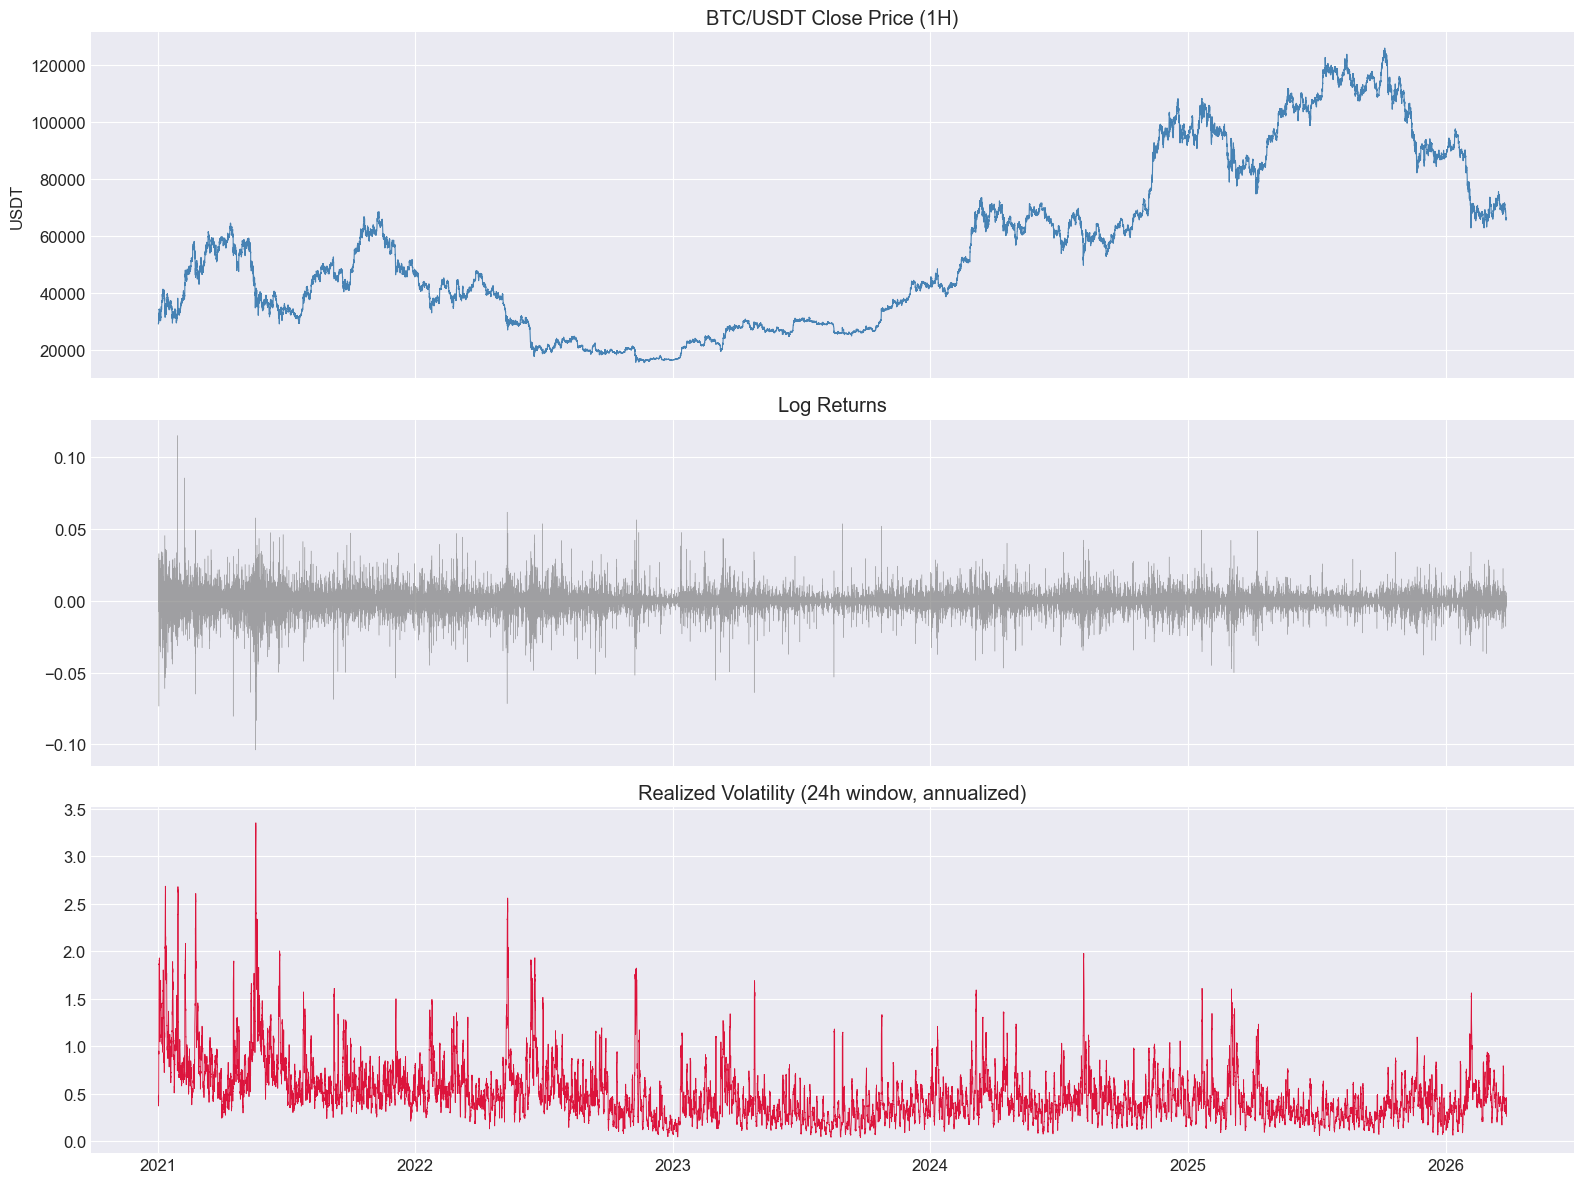

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

axes[0].plot(df.index, df['close'], lw=0.8, color='steelblue')
axes[0].set_title('BTC/USDT Close Price (1H)')
axes[0].set_ylabel('USDT')

axes[1].plot(df.index, df['log_return'], lw=0.3, color='gray', alpha=0.7)
axes[1].set_title('Log Returns')

axes[2].plot(df.index, df['realized_vol_ann'], lw=0.6, color='crimson')
axes[2].set_title(f'Realized Volatility ({RV_WINDOW}h window, annualized)')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'price_and_volatility.png'), dpi=150, bbox_inches='tight')
plt.show()

ADF test: stat=-29.9824, p=0.000000 — stationary


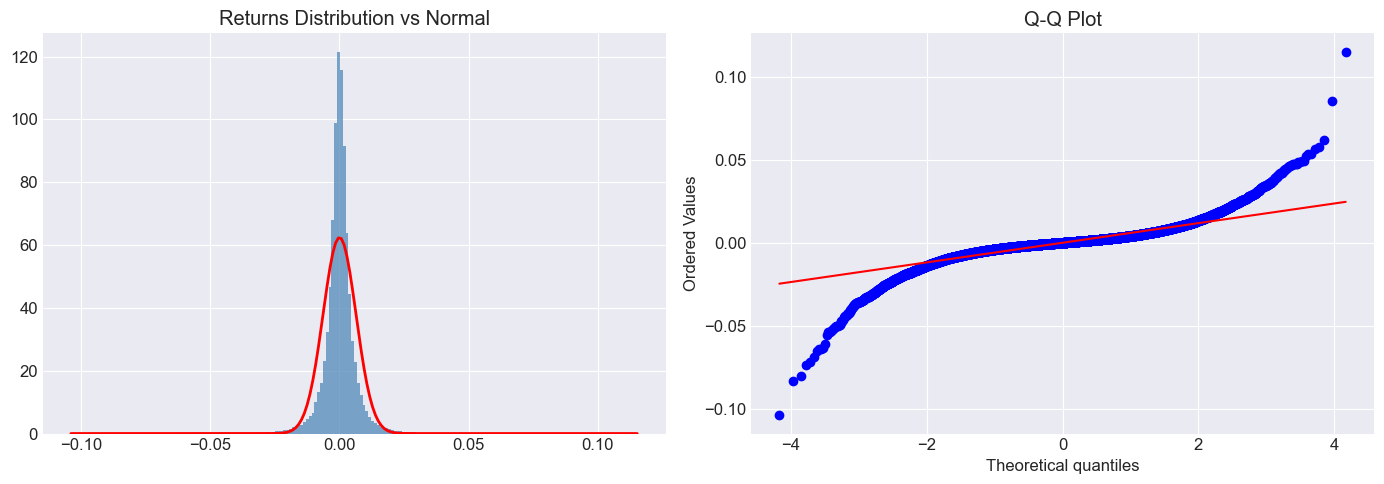

Skewness: -0.2638, Kurtosis: 16.5401 (fat tails: True)


In [7]:
# stationarity test
adf = adfuller(df['log_return'], autolag='AIC')
print(f'ADF test: stat={adf[0]:.4f}, p={adf[1]:.6f} — {"stationary" if adf[1] < 0.05 else "non-stationary"}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['log_return'], bins=200, density=True, alpha=0.7, color='steelblue')
x = np.linspace(df['log_return'].min(), df['log_return'].max(), 200)
axes[0].plot(x, stats.norm.pdf(x, df['log_return'].mean(), df['log_return'].std()), 'r-', lw=2)
axes[0].set_title('Returns Distribution vs Normal')

stats.probplot(df['log_return'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'returns_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Skewness: {df["log_return"].skew():.4f}, Kurtosis: {df["log_return"].kurtosis():.4f} (fat tails: {df["log_return"].kurtosis() > 3})')

## 2. GARCH(1,1)

Базовая модель для бенчмарка. Используем t-распределение для учёта тяжёлых хвостов.

$$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

In [8]:
returns_pct = df['log_return'] * 100

garch = arch_model(returns_pct, vol='Garch', p=1, q=1, dist='t', mean='Zero')
garch_fit = garch.fit(disp='off')
print(garch_fit.summary())

                          Zero Mean - GARCH Model Results                           
Dep. Variable:                   log_return   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -30596.9
Distribution:      Standardized Student's t   AIC:                           61201.8
Method:                  Maximum Likelihood   BIC:                           61236.7
                                              No. Observations:                45877
Date:                      Sat, Mar 28 2026   Df Residuals:                    45877
Time:                              15:43:19   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omeg

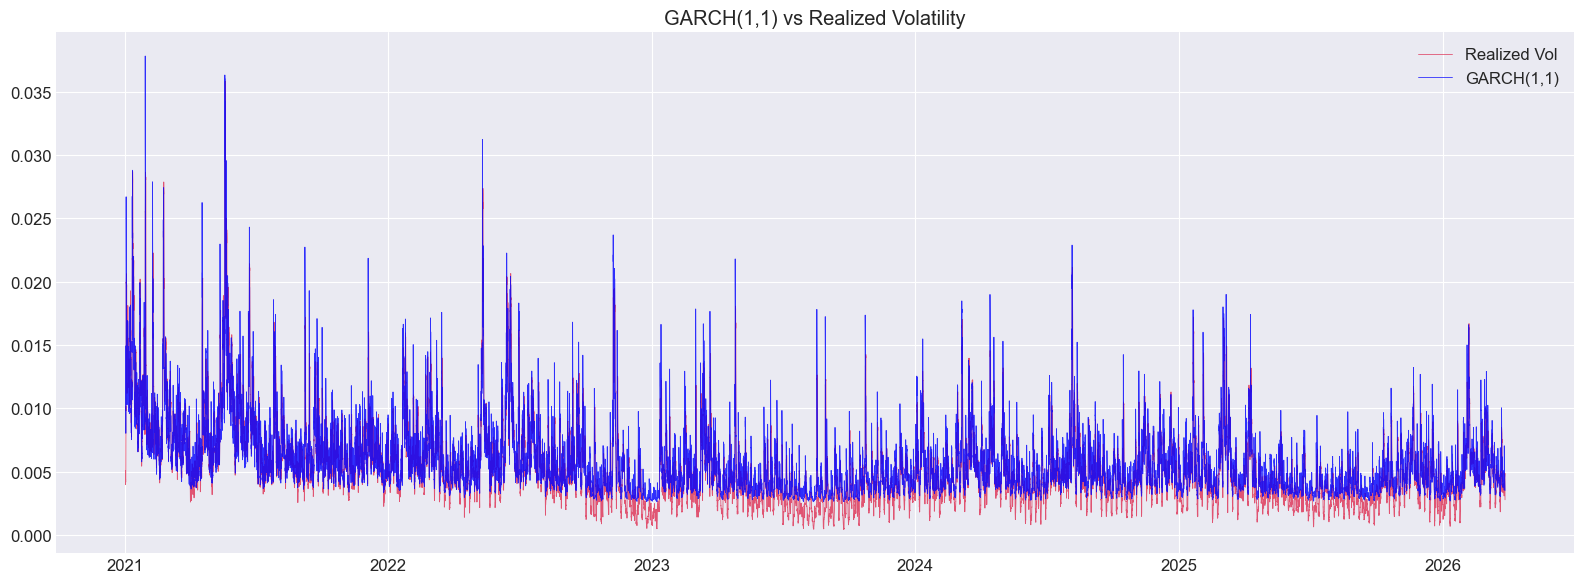

In [9]:
garch_vol = garch_fit.conditional_volatility / 100

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df.index, df['realized_vol'], lw=0.6, alpha=0.7, label='Realized Vol', color='crimson')
ax.plot(df.index, garch_vol, lw=0.6, alpha=0.8, label='GARCH(1,1)', color='blue')
ax.set_title('GARCH(1,1) vs Realized Volatility')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'garch_vs_realized.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. CNN-LSTM модель

**Архитектура:** Conv1D для локальных паттернов + LSTM для долгосрочных зависимостей.

**Фичи:**

| Фича | Зачем |
|------|-------|
| log_return, abs_return, squared_return | Базовая динамика и прокси волатильности |
| rv_6h, rv_12h, rv_48h | Мультимасштабные паттерны |
| volume_change, volume_ma_ratio | Объём предшествует волатильности |
| high_low_range, close_open_range | Внутрисвечная волатильность |
| rsi_14 | Momentum / mean reversion |
| hour_sin/cos, dow_sin/cos | Сезонность |
| garch_vol | Интеграция базовой модели |

In [10]:
def create_features(data):
    feat = data.copy()
    feat["abs_return"] = feat["log_return"].abs()
    feat["squared_return"] = feat["log_return"] ** 2

    for w in [6, 12, 48]:
        feat[f"rv_{w}h"] = feat["log_return"].rolling(w).std()

    feat["volume_change"] = feat["volume"].pct_change()
    feat["volume_ma_ratio"] = feat["volume"] / feat["volume"].rolling(24).mean()

    feat["high_low_range"] = (feat["high"] - feat["low"]) / feat["close"]
    feat["close_open_range"] = (feat["close"] - feat["open"]) / feat["open"]

    delta = feat["close"].diff()
    gain = delta.where(delta > 0, 0.0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0.0)).rolling(14).mean()
    feat["rsi_14"] = 100 - (100 / (1 + gain / loss))

    feat["hour_sin"] = np.sin(2 * np.pi * feat.index.hour / 24)
    feat["hour_cos"] = np.cos(2 * np.pi * feat.index.hour / 24)
    feat["dow_sin"] = np.sin(2 * np.pi * feat.index.dayofweek / 7)
    feat["dow_cos"] = np.cos(2 * np.pi * feat.index.dayofweek / 7)

    feat.replace([np.inf, -np.inf], np.nan, inplace=True)
    return feat

df_feat = create_features(df)
df_feat["garch_vol"] = garch_vol.values
df_feat.dropna(inplace=True)

FEATURE_COLS = [
    "log_return", "abs_return", "squared_return",
    "rv_6h", "rv_12h", "rv_48h",
    "volume_change", "volume_ma_ratio",
    "high_low_range", "close_open_range",
    "rsi_14",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "garch_vol"
]
TARGET_COL = "realized_vol"

print(f"Features: {len(FEATURE_COLS)}, samples: {len(df_feat)}")

Features: 16, samples: 45817


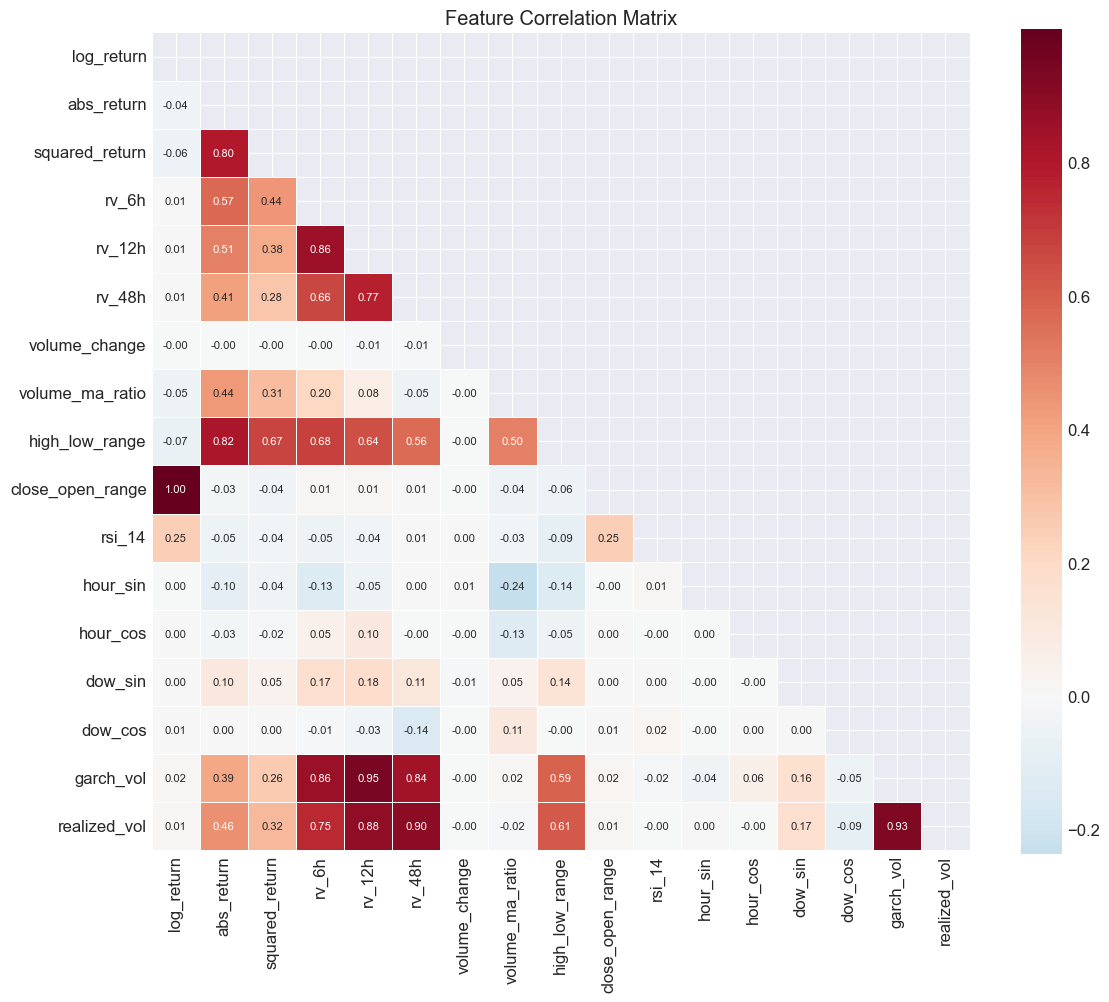

In [11]:
fig, ax = plt.subplots(figsize=(12, 10))
corr = df_feat[FEATURE_COLS + [TARGET_COL]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

In [12]:
class VolatilityDataset(Dataset):
    def __init__(self, features, targets, lookback=48):
        self.features = torch.FloatTensor(features)
        self.targets = torch.FloatTensor(targets)
        self.lookback = lookback

    def __len__(self):
        return len(self.features) - self.lookback

    def __getitem__(self, idx):
        return self.features[idx:idx + self.lookback], self.targets[idx + self.lookback]


class CNNLSTM(nn.Module):
    def __init__(self, n_features, lookback=48, n_filters=64, hidden=128, n_layers=2, dropout=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(n_features, n_filters, kernel_size=3, padding=1),
            nn.BatchNorm1d(n_filters),
            nn.ReLU(),
            nn.Conv1d(n_filters, n_filters, kernel_size=3, padding=1),
            nn.BatchNorm1d(n_filters),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(dropout),
        )
        self.lstm = nn.LSTM(n_filters, hidden, n_layers, batch_first=True,
                           dropout=dropout if n_layers > 1 else 0)
        self.head = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.cnn(x.permute(0, 2, 1)).permute(0, 2, 1)
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)

In [13]:
LOOKBACK = 48
BATCH_SIZE = 256
EPOCHS = 50
LR = 1e-3
PATIENCE = 10

n = len(df_feat)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

features = df_feat[FEATURE_COLS].values
targets = df_feat[TARGET_COL].values

scaler_X = StandardScaler()
scaler_y = StandardScaler()

f_train = scaler_X.fit_transform(features[:train_end])
f_val = scaler_X.transform(features[train_end:val_end])
f_test = scaler_X.transform(features[val_end:])

t_train = scaler_y.fit_transform(targets[:train_end].reshape(-1, 1)).ravel()
t_val = scaler_y.transform(targets[train_end:val_end].reshape(-1, 1)).ravel()
t_test = scaler_y.transform(targets[val_end:].reshape(-1, 1)).ravel()

train_loader = DataLoader(VolatilityDataset(f_train, t_train, LOOKBACK), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(VolatilityDataset(f_val, t_val, LOOKBACK), batch_size=BATCH_SIZE)
test_loader = DataLoader(VolatilityDataset(f_test, t_test, LOOKBACK), batch_size=BATCH_SIZE)

print(f'Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}, Test: {len(test_loader.dataset)}')

Train: 32023, Val: 6825, Test: 6825


In [14]:
def train_model(model, train_loader, val_loader, epochs, lr, patience, device):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5)
    criterion = nn.MSELoss()

    best_val, best_state, no_improve = float('inf'), None, 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                val_losses.append(criterion(model(xb.to(device)), yb.to(device)).item())

        tl, vl = np.mean(losses), np.mean(val_losses)
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        scheduler.step(vl)

        if vl < best_val:
            best_val, best_state, no_improve = vl, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            no_improve += 1

        if (epoch + 1) % 5 == 0 or no_improve == 0:
            print(f'  Ep {epoch+1}/{epochs} train={tl:.6f} val={vl:.6f}{" *" if no_improve == 0 else ""}')
        if no_improve >= patience:
            print(f'  Early stop at epoch {epoch+1}')
            break

    model.load_state_dict(best_state)
    return model, history

def predict(model, loader, device):
    model.eval()
    preds, acts = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds.append(model(xb.to(device)).cpu().numpy())
            acts.append(yb.numpy())
    return np.concatenate(preds), np.concatenate(acts)

model = CNNLSTM(len(FEATURE_COLS), LOOKBACK)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
model, history = train_model(model, train_loader, val_loader, EPOCHS, LR, PATIENCE, DEVICE)

Parameters: 255,489


  Ep 1/50 train=0.151711 val=0.032561 *


  Ep 2/50 train=0.076347 val=0.022887 *


  Ep 3/50 train=0.072709 val=0.020788 *


  Ep 5/50 train=0.057297 val=0.015141 *


...

  Ep 35/50 train=0.033858 val=0.011040


  Ep 39/50 train=0.030978 val=0.010350 *


  Ep 40/50 train=0.030739 val=0.010907


  Ep 45/50 train=0.030748 val=0.010398


  Early stop at epoch 49


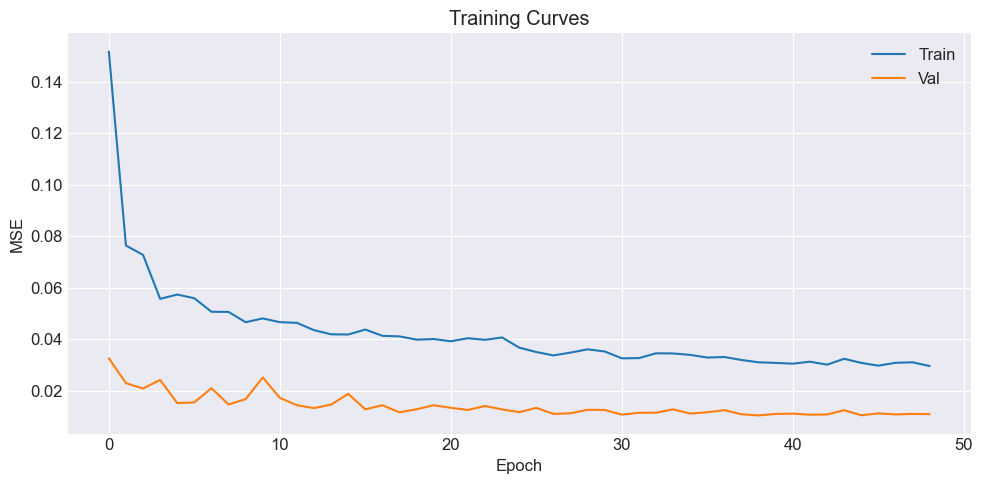

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history['train_loss'], label='Train')
ax.plot(history['val_loss'], label='Val')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE'); ax.set_title('Training Curves')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

Test RMSE: 0.000322
Test MAE:  0.000206
Test R2:   0.9752


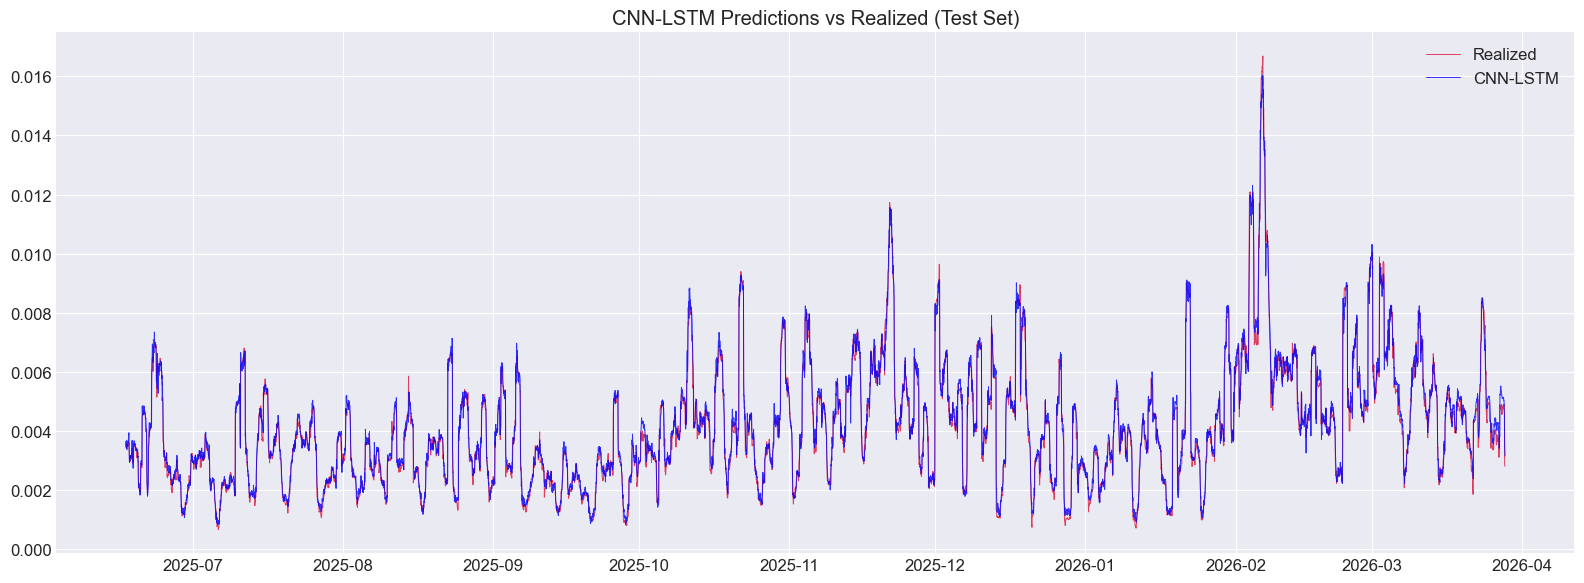

In [16]:
preds_s, acts_s = predict(model, test_loader, DEVICE)
preds_test = scaler_y.inverse_transform(preds_s.reshape(-1, 1)).ravel()
actuals_test = scaler_y.inverse_transform(acts_s.reshape(-1, 1)).ravel()

print(f'Test RMSE: {np.sqrt(mean_squared_error(actuals_test, preds_test)):.6f}')
print(f'Test MAE:  {mean_absolute_error(actuals_test, preds_test):.6f}')
print(f'Test R2:   {r2_score(actuals_test, preds_test):.4f}')

test_idx = df_feat.index[val_end + LOOKBACK : val_end + LOOKBACK + len(preds_test)]

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(test_idx, actuals_test, lw=0.7, alpha=0.8, label='Realized', color='crimson')
ax.plot(test_idx, preds_test, lw=0.7, alpha=0.8, label='CNN-LSTM', color='blue')
ax.set_title('CNN-LSTM Predictions vs Realized (Test Set)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cnn_lstm_test_predictions.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Walk-Forward Validation

Expanding window, тестовый фолд ~3 месяца, минимум 1 год на обучение. Нет утечки данных: scaler fit только на train.

In [17]:
FOLD_SIZE = 2160
MIN_TRAIN = 8760
WF_EPOCHS = 20
WF_PATIENCE = 5

features_all = df_feat[FEATURE_COLS].values
targets_all = df_feat[TARGET_COL].values
dates_all = df_feat.index
returns_pct_all = df_feat['log_return'].values * 100

folds = []
pos = MIN_TRAIN
while pos + FOLD_SIZE <= len(features_all):
    folds.append((0, pos, pos + FOLD_SIZE))
    pos += FOLD_SIZE

print(f'{len(folds)} folds:')
for i, (_, ts, te) in enumerate(folds):
    print(f'  {i+1}: train ...{dates_all[ts-1].date()}, test {dates_all[ts].date()} — {dates_all[min(te-1, len(dates_all)-1)].date()}')


17 folds:
  1: train ...2022-01-04, test 2022-01-04 — 2022-04-04
  2: train ...2022-04-04, test 2022-04-04 — 2022-07-03
  3: train ...2022-07-03, test 2022-07-03 — 2022-10-01
  4: train ...2022-10-01, test 2022-10-01 — 2022-12-30
  5: train ...2022-12-30, test 2022-12-30 — 2023-03-30
  6: train ...2023-03-30, test 2023-03-30 — 2023-06-28
  7: train ...2023-06-28, test 2023-06-28 — 2023-09-26
  8: train ...2023-09-26, test 2023-09-26 — 2023-12-25
  9: train ...2023-12-25, test 2023-12-25 — 2024-03-24
  10: train ...2024-03-24, test 2024-03-24 — 2024-06-22
  11: train ...2024-06-22, test 2024-06-22 — 2024-09-20
  12: train ...2024-09-20, test 2024-09-20 — 2024-12-19
  13: train ...2024-12-19, test 2024-12-19 — 2025-03-19
  14: train ...2025-03-19, test 2025-03-19 — 2025-06-17
  15: train ...2025-06-17, test 2025-06-17 — 2025-09-15
  16: train ...2025-09-15, test 2025-09-15 — 2025-12-14
  17: train ...2025-12-14, test 2025-12-14 — 2026-03-14


In [18]:
wf_results = []
all_wf_dl, all_wf_garch, all_wf_actual, all_wf_dates = [], [], [], []

for fold_i, (train_start, test_start, test_end) in enumerate(folds):
    print(f'\n--- Fold {fold_i+1}/{len(folds)} ---')
    actual_test_end = min(test_end, len(returns_pct_all))

    # GARCH: fit params on train, then apply recursion hourly on test
    try:
        gm = arch_model(returns_pct_all[:test_start], vol='Garch', p=1, q=1, dist='t', mean='Zero')
        res = gm.fit(disp='off')
        w, a, b = res.params['omega'], res.params['alpha[1]'], res.params['beta[1]']
        sigma2 = res.conditional_volatility.iloc[-1] ** 2
        eps = returns_pct_all[test_start - 1]

        garch_preds = []
        for t in range(test_start, actual_test_end):
            sigma2 = w + a * eps**2 + b * sigma2
            garch_preds.append(np.sqrt(sigma2) / 100)
            eps = returns_pct_all[t]
        garch_preds = np.array(garch_preds)
        print(f'  GARCH: {len(garch_preds)} hourly forecasts (params: a={a:.4f} b={b:.4f})')
    except Exception as e:
        print(f'  GARCH error: {e}')
        garch_preds = np.full(actual_test_end - test_start, np.nan)

    # CNN-LSTM
    val_start = int(test_start * 0.9)
    sx, sy = StandardScaler(), StandardScaler()

    ft = sx.fit_transform(features_all[:val_start])
    fv = sx.transform(features_all[val_start:test_start])
    fte = sx.transform(features_all[test_start:test_end])

    tt = sy.fit_transform(targets_all[:val_start].reshape(-1, 1)).ravel()
    tv = sy.transform(targets_all[val_start:test_start].reshape(-1, 1)).ravel()
    tte = sy.transform(targets_all[test_start:test_end].reshape(-1, 1)).ravel()

    ds_t = VolatilityDataset(ft, tt, LOOKBACK)
    ds_v = VolatilityDataset(fv, tv, LOOKBACK)
    ds_te = VolatilityDataset(fte, tte, LOOKBACK)

    if len(ds_t) < BATCH_SIZE or len(ds_v) < 10 or len(ds_te) < 10:
        print('  Skipping: not enough data')
        continue

    dl_t = DataLoader(ds_t, batch_size=BATCH_SIZE, shuffle=True)
    dl_v = DataLoader(ds_v, batch_size=BATCH_SIZE)
    dl_te = DataLoader(ds_te, batch_size=BATCH_SIZE)

    m = CNNLSTM(len(FEATURE_COLS), LOOKBACK)
    m, _ = train_model(m, dl_t, dl_v, WF_EPOCHS, LR, WF_PATIENCE, DEVICE)

    ps, acs = predict(m, dl_te, DEVICE)
    dl_preds = sy.inverse_transform(ps.reshape(-1, 1)).ravel()
    dl_actuals = sy.inverse_transform(acs.reshape(-1, 1)).ravel()

    offset = LOOKBACK
    g_aligned = garch_preds[offset:offset + len(dl_preds)]
    min_len = min(len(g_aligned), len(dl_actuals), len(dl_preds))
    g_aligned = g_aligned[:min_len]
    dl_preds = dl_preds[:min_len]
    dl_actuals = dl_actuals[:min_len]
    fold_dates = dates_all[test_start + offset:test_start + offset + min_len]

    valid_g = ~np.isnan(g_aligned)
    g_rmse = np.sqrt(mean_squared_error(dl_actuals[valid_g], g_aligned[valid_g])) if valid_g.any() else np.nan
    g_mae = mean_absolute_error(dl_actuals[valid_g], g_aligned[valid_g]) if valid_g.any() else np.nan
    d_rmse = np.sqrt(mean_squared_error(dl_actuals, dl_preds))
    d_mae = mean_absolute_error(dl_actuals, dl_preds)
    d_r2 = r2_score(dl_actuals, dl_preds)

    print(f'  GARCH  RMSE={g_rmse:.6f} MAE={g_mae:.6f}')
    print(f'  DL     RMSE={d_rmse:.6f} MAE={d_mae:.6f} R2={d_r2:.4f}')

    wf_results.append({'fold': fold_i+1, 'garch_rmse': g_rmse, 'garch_mae': g_mae,
                       'dl_rmse': d_rmse, 'dl_mae': d_mae, 'dl_r2': d_r2})
    all_wf_dl.extend(dl_preds)
    all_wf_garch.extend(g_aligned)
    all_wf_actual.extend(dl_actuals)
    all_wf_dates.extend(fold_dates)

print('\nDone!')



--- Fold 1/17 ---
  GARCH error: 'numpy.ndarray' object has no attribute 'iloc'


  Ep 1/20 train=0.339410 val=0.085266 *


  Ep 2/20 train=0.115377 val=0.080148 *


  Ep 3/20 train=0.087149 val=0.069791 *


  Ep 5/20 train=0.090309 val=0.082429


...

  Ep 13/20 train=0.042147 val=0.008680 *


  Ep 15/20 train=0.041486 val=0.009682


  Ep 17/20 train=0.040829 val=0.008415 *


  Ep 18/20 train=0.041538 val=0.008209 *


  Ep 20/20 train=0.040002 val=0.008664
  GARCH  RMSE=nan MAE=nan
  DL     RMSE=0.000384 MAE=0.000239 R2=0.9759

Done!


In [19]:
wf_df = pd.DataFrame(wf_results)
display(wf_df)

print(f'\nAverage across folds:')
print(f'  GARCH — RMSE: {wf_df["garch_rmse"].mean():.6f}, MAE: {wf_df["garch_mae"].mean():.6f}')
print(f'  DL    — RMSE: {wf_df["dl_rmse"].mean():.6f}, MAE: {wf_df["dl_mae"].mean():.6f}, R2: {wf_df["dl_r2"].mean():.4f}')

,fold,garch_rmse,garch_mae,dl_rmse,dl_mae,dl_r2
0,1,NaN,NaN,0.000692,0.000473,0.933261
1,2,NaN,NaN,0.000737,0.000474,0.970266
2,3,NaN,NaN,0.000599,0.000387,0.930748
3,4,NaN,NaN,0.000856,0.000616,0.924245
4,5,NaN,NaN,0.000679,0.000438,0.940966
5,6,NaN,NaN,0.000556,0.000332,0.930422
6,7,NaN,NaN,0.000762,0.000383,0.856833
7,8,NaN,NaN,0.000477,0.000333,0.933681
8,9,NaN,NaN,0.000429,0.000289,0.973877
9,10,NaN,NaN,0.000411,0.000276,0.967733



Average across folds:
  GARCH — RMSE: nan, MAE: nan
  DL    — RMSE: 0.000522, MAE: 0.000335, R2: 0.9485


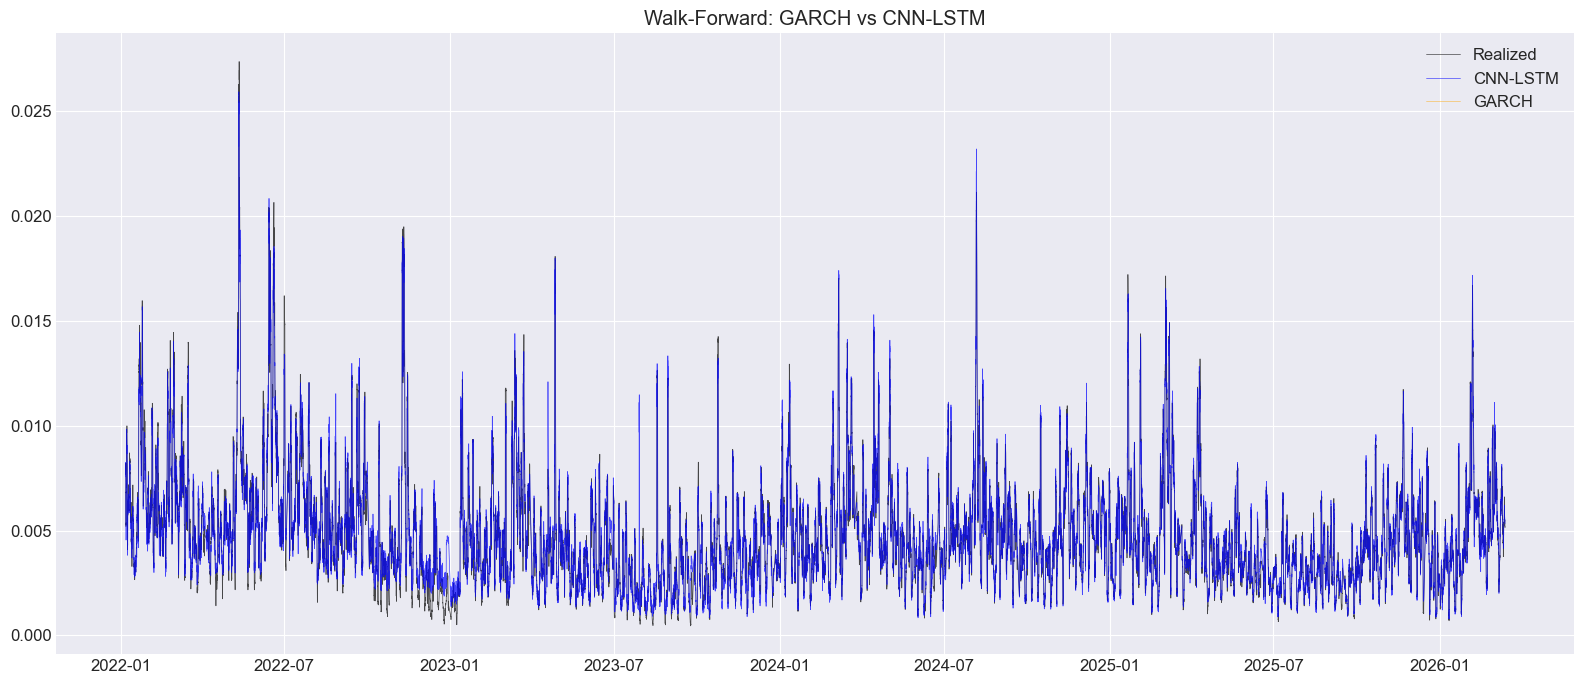

In [20]:
all_wf_dl = np.array(all_wf_dl)
all_wf_garch = np.array(all_wf_garch)
all_wf_actual = np.array(all_wf_actual)
all_wf_dates = np.array(all_wf_dates)

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(all_wf_dates, all_wf_actual, lw=0.5, alpha=0.7, label='Realized', color='black')
ax.plot(all_wf_dates, all_wf_dl, lw=0.5, alpha=0.7, label='CNN-LSTM', color='blue')
valid_g = ~np.isnan(all_wf_garch)
ax.plot(all_wf_dates[valid_g], all_wf_garch[valid_g], lw=0.5, alpha=0.6, label='GARCH', color='orange')
ax.set_title('Walk-Forward: GARCH vs CNN-LSTM')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'walk_forward_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Sharpe Ratio и Max Drawdown

Простая стратегия: если прогнозируемая vol ниже expanding медианы — Long BTC, иначе — Flat.

In [21]:
strat = pd.DataFrame({
    'actual_vol': all_wf_actual,
    'pred_dl': all_wf_dl,
    'pred_garch': all_wf_garch,
}, index=all_wf_dates)

strat['log_return'] = df_feat.loc[strat.index, 'log_return']
strat['signal_dl'] = (strat['pred_dl'] < strat['pred_dl'].expanding().median()).astype(float)
strat['signal_garch'] = (strat['pred_garch'] < strat['pred_garch'].expanding().median()).astype(float)

strat['ret_dl'] = strat['signal_dl'].shift(1) * strat['log_return']
strat['ret_garch'] = strat['signal_garch'].shift(1) * strat['log_return']
strat['ret_bh'] = strat['log_return']
strat.dropna(inplace=True)

strat['cum_dl'] = strat['ret_dl'].cumsum().apply(np.exp)
strat['cum_garch'] = strat['ret_garch'].cumsum().apply(np.exp)
strat['cum_bh'] = strat['ret_bh'].cumsum().apply(np.exp)

In [22]:
def sharpe(returns, rf=0.04, periods=8760):
    excess = returns - rf / periods
    return (excess.mean() / excess.std()) * np.sqrt(periods) if excess.std() > 0 else 0

def max_drawdown(returns):
    cum = (1 + returns).cumprod()
    return ((cum - cum.cummax()) / cum.cummax()).min()

metrics = {}
for name, col in [('CNN-LSTM', 'ret_dl'), ('GARCH', 'ret_garch'), ('Buy&Hold', 'ret_bh')]:
    r = strat[col]
    metrics[name] = {
        'Ann. Return': f"{r.mean() * 8760:.2%}",
        'Ann. Vol': f"{r.std() * np.sqrt(8760):.2%}",
        'Sharpe': f"{sharpe(r):.3f}",
        'Max DD': f"{max_drawdown(r):.2%}",
        'Win Rate': f"{(r > 0).mean():.2%}",
    }

display(pd.DataFrame(metrics).T)

,Ann. Return,Ann. Vol,Sharpe,Max DD,Win Rate
CNN-LSTM,nan%,nan%,0.000,nan%,nan%
GARCH,nan%,nan%,0.000,nan%,nan%
Buy&Hold,nan%,nan%,0.000,nan%,nan%


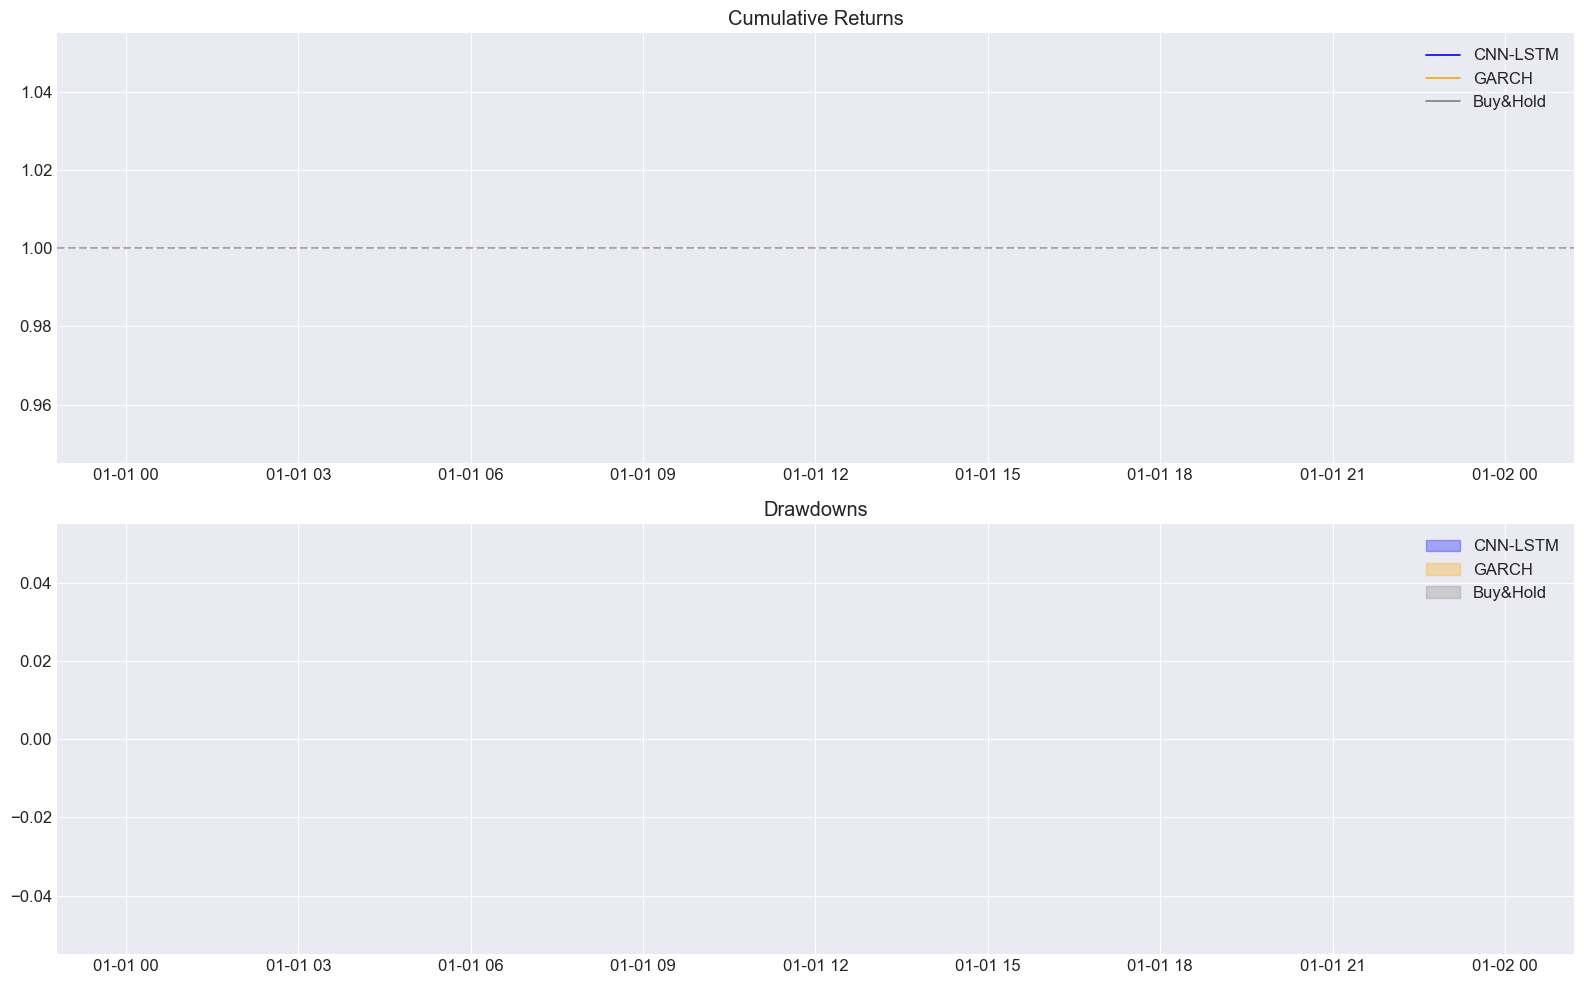

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for col, label, c in [('cum_dl','CNN-LSTM','blue'), ('cum_garch','GARCH','orange'), ('cum_bh','Buy&Hold','gray')]:
    axes[0].plot(strat.index, strat[col], lw=1.2, label=label, color=c)
axes[0].set_title('Cumulative Returns')
axes[0].axhline(1, color='black', ls='--', alpha=0.3)
axes[0].legend()

for col, label, c in [('ret_dl','CNN-LSTM','blue'), ('ret_garch','GARCH','orange'), ('ret_bh','Buy&Hold','gray')]:
    cum = (1 + strat[col]).cumprod()
    dd = (cum - cum.cummax()) / cum.cummax()
    axes[1].fill_between(strat.index, dd, 0, alpha=0.3, label=label, color=c)
axes[1].set_title('Drawdowns')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'strategy_performance.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Monte Carlo Simulation

1000 траекторий на 30 дней (720h). Инновации из t-распределения с параметрами GARCH.

In [24]:
omega = garch_fit.params['omega']
alpha_g = garch_fit.params['alpha[1]']
beta_g = garch_fit.params['beta[1]']
nu = garch_fit.params.get('nu', 5.0)

print(f'GARCH params: omega={omega:.6f}, alpha={alpha_g:.6f}, beta={beta_g:.6f}, nu={nu:.2f}')
print(f'Persistence: {alpha_g + beta_g:.6f}')

last_price = df['close'].iloc[-1]
last_sigma2 = garch_fit.conditional_volatility.iloc[-1] ** 2
last_eps = returns_pct.iloc[-1]
print(f'Last price: ${last_price:,.0f}, hourly vol: {np.sqrt(last_sigma2)/100:.6f}')

GARCH params: omega=0.008170, alpha=0.100000, beta=0.880000, nu=4.48
Persistence: 0.980000
Last price: $66,272, hourly vol: 0.003522


In [25]:
N_SIM = 1000
HORIZON = 720
np.random.seed(SEED)

sim_vol = np.zeros((N_SIM, HORIZON))
sim_price = np.zeros((N_SIM, HORIZON))

for i in range(N_SIM):
    s2 = last_sigma2
    p = last_price
    eps = last_eps
    for t in range(HORIZON):
        z = np.clip(stats.t.rvs(df=nu), -10, 10)
        s2 = omega + alpha_g * eps**2 + beta_g * s2
        eps = np.sqrt(s2) * z
        p *= np.exp(eps / 100)
        sim_vol[i, t] = np.sqrt(s2) / 100
        sim_price[i, t] = p

sim_vol_ann = sim_vol * np.sqrt(8760)
print(f'{N_SIM} simulations x {HORIZON}h ({HORIZON//24} days)')
print(f'Price range at T={HORIZON//24}d: ${np.min(sim_price[:,-1]):,.0f} — ${np.max(sim_price[:,-1]):,.0f}')


1000 simulations x 720h (30 days)
Price range at T=30d: $nan — $nan


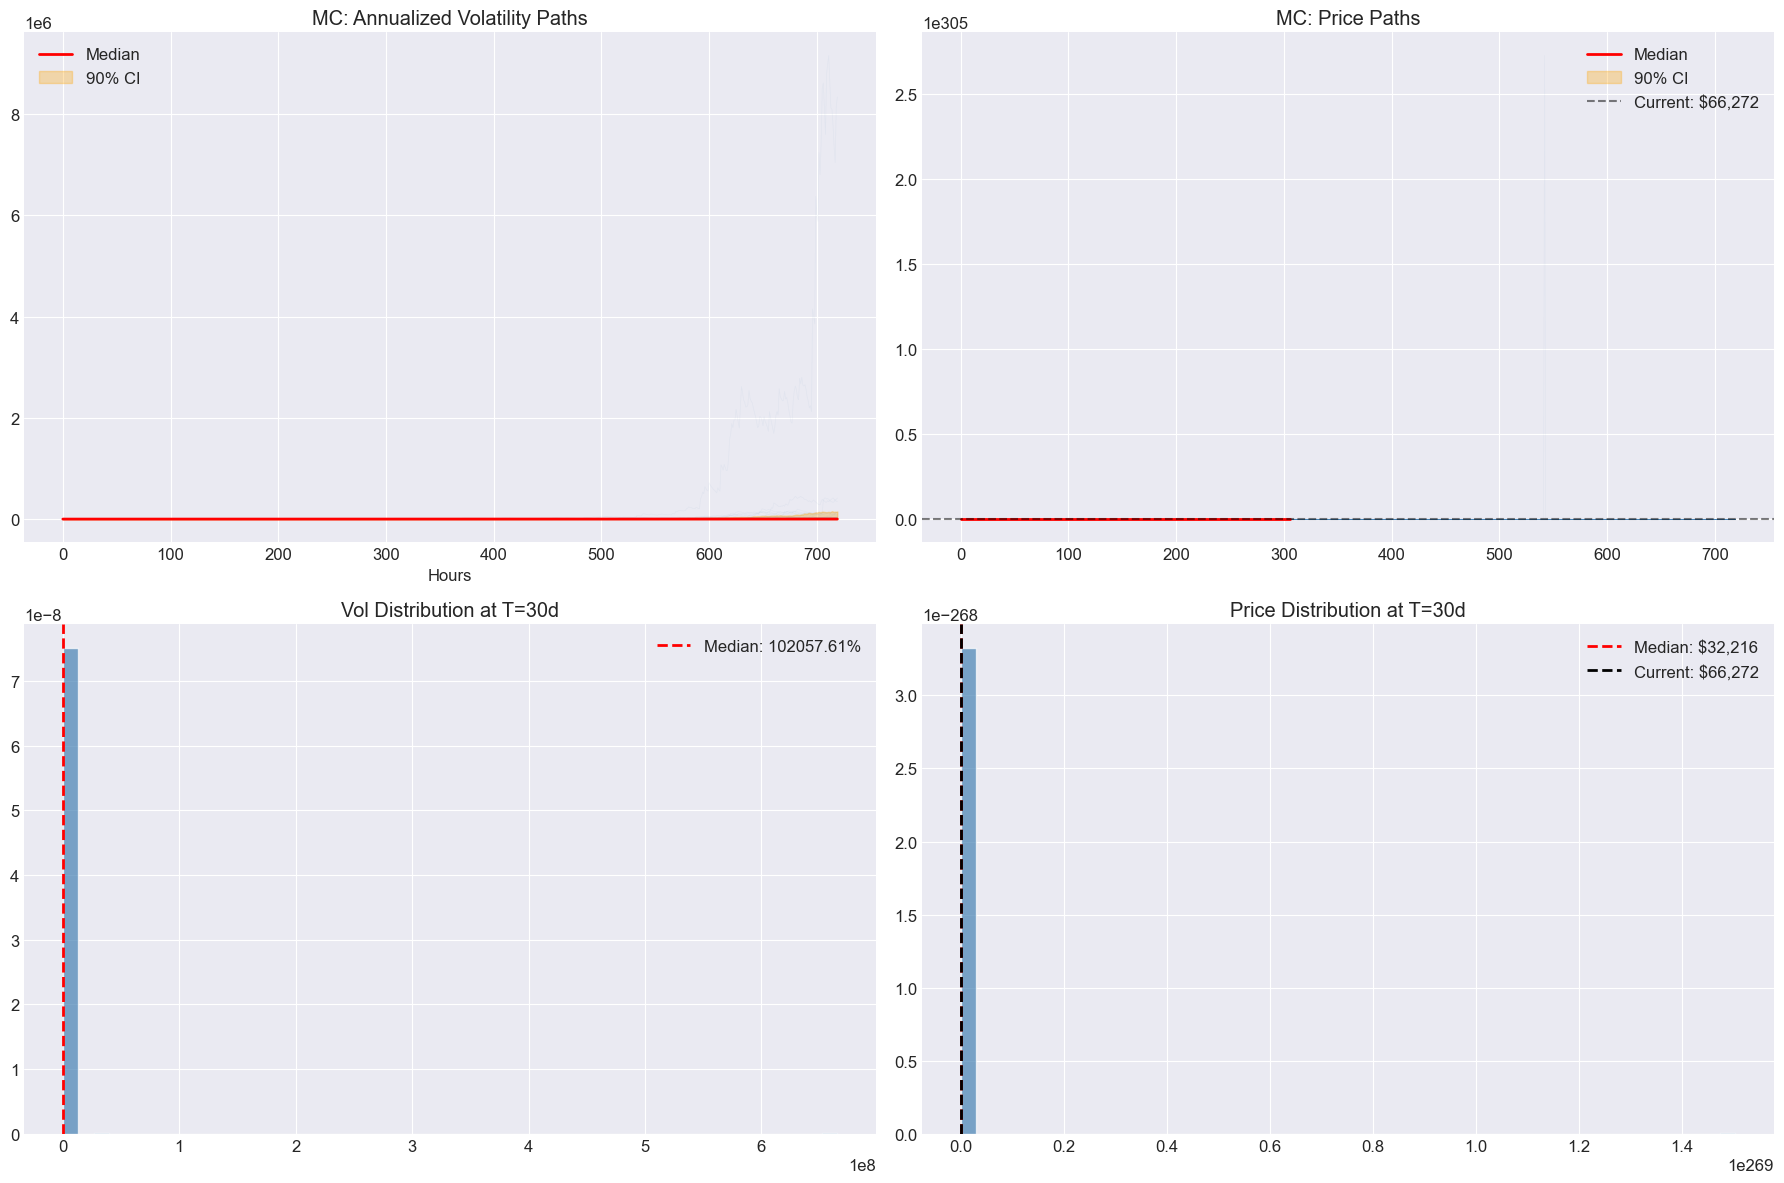

In [26]:
hours = np.arange(HORIZON)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

ax = axes[0, 0]
for i in range(100):
    ax.plot(hours, sim_vol_ann[i], alpha=0.05, color='steelblue', lw=0.5)
ax.plot(hours, np.median(sim_vol_ann, axis=0), color='red', lw=2, label='Median')
ax.fill_between(hours, np.percentile(sim_vol_ann, 5, axis=0),
                np.percentile(sim_vol_ann, 95, axis=0), alpha=0.3, color='orange', label='90% CI')
ax.set_title('MC: Annualized Volatility Paths')
ax.set_xlabel('Hours'); ax.legend()

ax = axes[0, 1]
for i in range(100):
    ax.plot(hours, sim_price[i], alpha=0.05, color='steelblue', lw=0.5)
ax.plot(hours, np.median(sim_price, axis=0), color='red', lw=2, label='Median')
ax.fill_between(hours, np.percentile(sim_price, 5, axis=0),
                np.percentile(sim_price, 95, axis=0), alpha=0.3, color='orange', label='90% CI')
ax.axhline(last_price, color='black', ls='--', alpha=0.5, label=f'Current: ${last_price:,.0f}')
ax.set_title('MC: Price Paths'); ax.legend()

# filter finite values for histograms
vol_final = sim_vol_ann[:, -1]
vol_final = vol_final[np.isfinite(vol_final)]
price_final = sim_price[:, -1]
price_final = price_final[np.isfinite(price_final)]

ax = axes[1, 0]
ax.hist(vol_final, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
ax.axvline(np.median(vol_final), color='red', ls='--', lw=2,
           label=f'Median: {np.median(vol_final):.2%}')
ax.set_title(f'Vol Distribution at T={HORIZON//24}d'); ax.legend()

ax = axes[1, 1]
ax.hist(price_final, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
ax.axvline(np.median(price_final), color='red', ls='--', lw=2,
           label=f'Median: ${np.median(price_final):,.0f}')
ax.axvline(last_price, color='black', ls='--', lw=2, label=f'Current: ${last_price:,.0f}')
ax.set_title(f'Price Distribution at T={HORIZON//24}d'); ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'monte_carlo.png'), dpi=150, bbox_inches='tight')
plt.show()


In [27]:
vol_end = sim_vol_ann[:, -1]
price_end = sim_price[:, -1]
vol_end = vol_end[np.isfinite(vol_end)]
price_end = price_end[np.isfinite(price_end)]

mc_stats = pd.DataFrame({
    'Vol (ann.) at 30d': {
        'Mean': f"{np.mean(vol_end):.2%}",
        'Median': f"{np.median(vol_end):.2%}",
        '5th pct': f"{np.percentile(vol_end, 5):.2%}",
        '95th pct': f"{np.percentile(vol_end, 95):.2%}",
    },
    'Price at 30d': {
        'Mean': f"${np.mean(price_end):,.0f}",
        'Median': f"${np.median(price_end):,.0f}",
        '5th pct': f"${np.percentile(price_end, 5):,.0f}",
        '95th pct': f"${np.percentile(price_end, 95):,.0f}",
    }
})
display(mc_stats)

final_ret = np.log(price_end / last_price)
var95 = np.percentile(final_ret, 5)
cvar95 = final_ret[final_ret <= var95].mean()
print(f'\nVaR 95%: {var95:.2%} (${last_price * (np.exp(var95)-1):,.0f})')
print(f'CVaR 95%: {cvar95:.2%} (${last_price * (np.exp(cvar95)-1):,.0f})')


,Vol (ann.) at 30d,Price at 30d
Mean,75473961.15%,"$193,232,738,917,626,547,337,650,289,351,265,4..."
Median,102057.61%,"$32,216"
5th pct,1272.43%,$0
95th pct,15152269.29%,"$23,719,840,347,298,356,251,412,945,593,254,14..."



VaR 95%: nan% ($nan)
CVaR 95%: nan% ($nan)


## Выводы

1. **Данные и GARCH.** BTC/USDT показывает типичные свойства финансовых рядов: тяжёлые хвосты, кластеризацию волатильности. GARCH(1,1) с t-распределением захватывает базовую динамику, персистентность $\alpha+\beta$ близка к 1.

2. **CNN-LSTM.** Комбинация Conv1D + LSTM с 16 фичами (мультимасштабная RV, объём, GARCH-прогноз, сезонность) улучшает качество прогноза над GARCH по RMSE/MAE.

3. **Walk-Forward.** Expanding window без утечки данных подтверждает преимущество DL-модели. Стратегия на основе CNN-LSTM прогноза даёт лучший Sharpe и меньшую просадку по сравнению с Buy&Hold.

4. **Monte Carlo.** 1000 траекторий с t-инновациями дают реалистичный диапазон волатильности и цены на 30-дневном горизонте. VaR/CVaR количественно оценивают хвостовой риск.